# Trabajo de Fin de Curso: Machine Learning Avanzado
## Casos de Estudio: Sesgo de Supervivencia (SGM) y Eficacia de Defensa Aérea en la Guerra de Ucrania

Este Jupyter Notebook contiene el desarrollo, análisis y optimización de dos proyectos de Machine Learning orientados a la sustentación académica, implementando el ciclo de vida completo de la ciencia de datos:

1. **Preprocesamiento e Ingeniería de Características Avanzada**
2. **Limpieza de Datos, Detección de Outliers e Imputación**
3. **Escalado de Características y Codificación (One-Hot Encoding)**
4. **Validación Cruzada Estratificada y Entrenamiento de Modelos**
5. **Ajuste Fino de Hiperparámetros (Grid Search Tuning)**
6. **Análisis de Métricas de Rendimiento Completo (Curvas ROC/AUC, Matrices de Confusión, Recall vs Precision)**
7. **Estrategias y Conclusiones de Negocio/Operaciones**

---
### Entorno de Ejecución
Este notebook está preparado para ejecutarse utilizando el kernel de Python de tu entorno virtual (`.venv`), el cual ya contiene todas las librerías necesarias (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `xgboost`).

# PARTE 1: El Sesgo de Supervivencia (Abraham Wald y los Aviones de la SGM)

### Contexto Histórico
Durante la Segunda Guerra Mundial, el matemático **Abraham Wald** trabajó para el Grupo de Investigación Estadística (SRG) de la Universidad de Columbia. La Fuerza Aérea Aliada quería reforzar el blindaje de sus bombarderos B-17 para reducir las pérdidas. Al analizar los impactos de bala en los aviones que regresaban de combate, observaron que las alas y el fuselaje presentaban la mayor cantidad de daños, mientras que la cabina y los motores casi no tenían impactos.

Los militares decidieron blindar las alas y el fuselaje. Wald intervino explicando el **sesgo de supervivencia**: los aviones con impactos en la cabina y motores no regresaban porque esos daños eran letales. La muestra observada estaba sesgada hacia los supervivientes. Wald sugirió blindar las zonas donde **no** se observaban impactos.

### Enfoque Metodológico de ML
Demostraremos cuantitativamente cómo entrenar modelos con muestras sesgadas corrompe el aprendizaje automático y genera predicciones equivocadas.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

# Configurar semilla para reproducibilidad
np.random.seed(42)
sns.set_theme(style="whitegrid")
print("Librerías cargadas y configuradas.")

Librerías cargadas y configuradas.


## 1. Simulación de Monte Carlo: Generación de Datos

Simularemos $10,000$ misiones de aviones. El avión consta de 4 zonas. Para reproducir fielmente la paradoja histórica de Wald y el gráfico de vacíos de impactos en los supervivientes, definiremos las probabilidades físicas reales de derribo de forma estricta:
- **Cabina (Cockpit):** Daño crítico absoluto. Probabilidad de derribo = 100% (1.0). Si recibe un impacto en la cabina, el avión cae siempre.
- **Motores (Engines):** Daño crítico absoluto. Probabilidad de derribo = 100% (1.0). Si recibe un impacto en el motor, el avión cae siempre.
- **Alas (Wings):** Daño puramente cosmético/estructural tolerable. Probabilidad de derribo = 0% (0.0). El avión puede recibir infinitos disparos aquí y sobrevive.
- **Fuselaje (Fuselage):** Daño estructural tolerable. Probabilidad de derribo = 0% (0.0). El avión sobrevive siempre a impactos aquí.

In [ ]:
def clasificar_zona(x, y):
    # Cabina
    if (x**2 + (y-7.5)**2) <= 1.2**2:
        return 'Cabina'
    # Motores
    if ((-4 <= x <= -2.8) or (2.8 <= x <= 4)) and (0.5 <= y <= 3):
        return 'Motores'
    # Alas
    if (y >= 0 and y <= 3) and (abs(x) > 1.5):
        return 'Alas'
    # Fuselaje y Cola
    if (-1.5 <= x <= 1.5) and (-8 <= y <= 8):
        return 'Fuselaje'
    if (y < 0) and (abs(x) <= 3) and (y >= -8):
        return 'Fuselaje'
    return None

def simular_aviones(n_aviones=10000):
    aviones = []
    impactos_totales = []
    
    for i in range(n_aviones):
        n_impactos = np.random.randint(1, 6) # De 1 a 5 impactos aleatorios del fuego antiaéreo
        impactos_avion = []
        sobrevive = 1
        conteos = {'Cabina': 0, 'Motores': 0, 'Alas': 0, 'Fuselaje': 0}
        
        j = 0
        while j < n_impactos:
            x = np.random.uniform(-10, 10)
            y = np.random.uniform(-8, 9)
            
            zona = clasificar_zona(x, y)
            if zona is not None:
                conteos[zona] += 1
                impactos_avion.append((x, y, zona))
                
                # Letalidad de impacto por zona (Física oculta real)
                # 1.0 significa letalidad absoluta (100%), 0.0 significa inocuo (0%)
                prob_derribo = {'Cabina': 1.0, 'Motores': 1.0, 'Alas': 0.0, 'Fuselaje': 0.0}[zona]
                
                if prob_derribo == 1.0:
                    sobrevive = 0
                j += 1
                
        aviones.append({
            'id': i,
            'impactos_cabina': conteos['Cabina'],
            'impactos_motores': conteos['Motores'],
            'impactos_alas': conteos['Alas'],
            'impactos_fuselaje': conteos['Fuselaje'],
            'sobreviviente': sobrevive
        })
        
        for imp in impactos_avion:
            impactos_totales.append({
                'avion_id': i,
                'x': imp[0],
                'y': imp[1],
                'zona': imp[2],
                'sobrevive_avion': sobrevive
            })
            
    return pd.DataFrame(aviones), pd.DataFrame(impactos_totales)

df_aviones, df_impactos = simular_aviones(10000)
print(f"Aviones simulados: {len(df_aviones)}")
print(f"Tasa real de supervivencia: {df_aviones['sobreviviente'].mean():.2%}")

Aviones simulados: 10000
Tasa real de supervivencia: 76.86%


In [124]:
df_aviones.head()

,id,impactos_cabina,impactos_motores,impactos_alas,impactos_fuselaje,sobreviviente
0,0,0,0,2,2,1
1,1,0,0,0,2,1
2,2,0,0,1,0,1
3,3,0,0,1,2,1
4,4,0,1,1,2,0


In [125]:
df_aviones.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 10000 non-null  int64
 1   impactos_cabina    10000 non-null  int64
 2   impactos_motores   10000 non-null  int64
 3   impactos_alas      10000 non-null  int64
 4   impactos_fuselaje  10000 non-null  int64
 5   sobreviviente      10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [126]:
df_impactos.head()

,avion_id,x,y,zona,sobrevive_avion
0,0,1.973170,-5.347683,Fuselaje,1
1,0,7.323523,2.218955,Alas,1
2,0,0.495129,-0.656935,Fuselaje,1
3,0,-4.175417,2.401499,Alas,1
4,1,2.367720,-1.498146,Fuselaje,1


In [127]:
df_impactos.info()

<class 'pandas.DataFrame'>
RangeIndex: 30094 entries, 0 to 30093
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   avion_id         30094 non-null  int64  
 1   x                30094 non-null  float64
 2   y                30094 non-null  float64
 3   zona             30094 non-null  str    
 4   sobrevive_avion  30094 non-null  int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 1.1 MB


## 2. Visualización e Inferencia del Sesgo de Selección

Graficaremos un mapa de densidad para ver dónde impactan los proyectiles enemigos en los aviones que regresaron (perspectiva militar sesgada) frente a dónde impactaron en todos los aviones (realidad completa).

![Sesgo de supervivencia (diagrama clásico de Wald)][def]

*Fuente: McGeddon, Wikimedia Commons (CC BY-SA 4.0).*

[def]: Survivorship-bias.svg

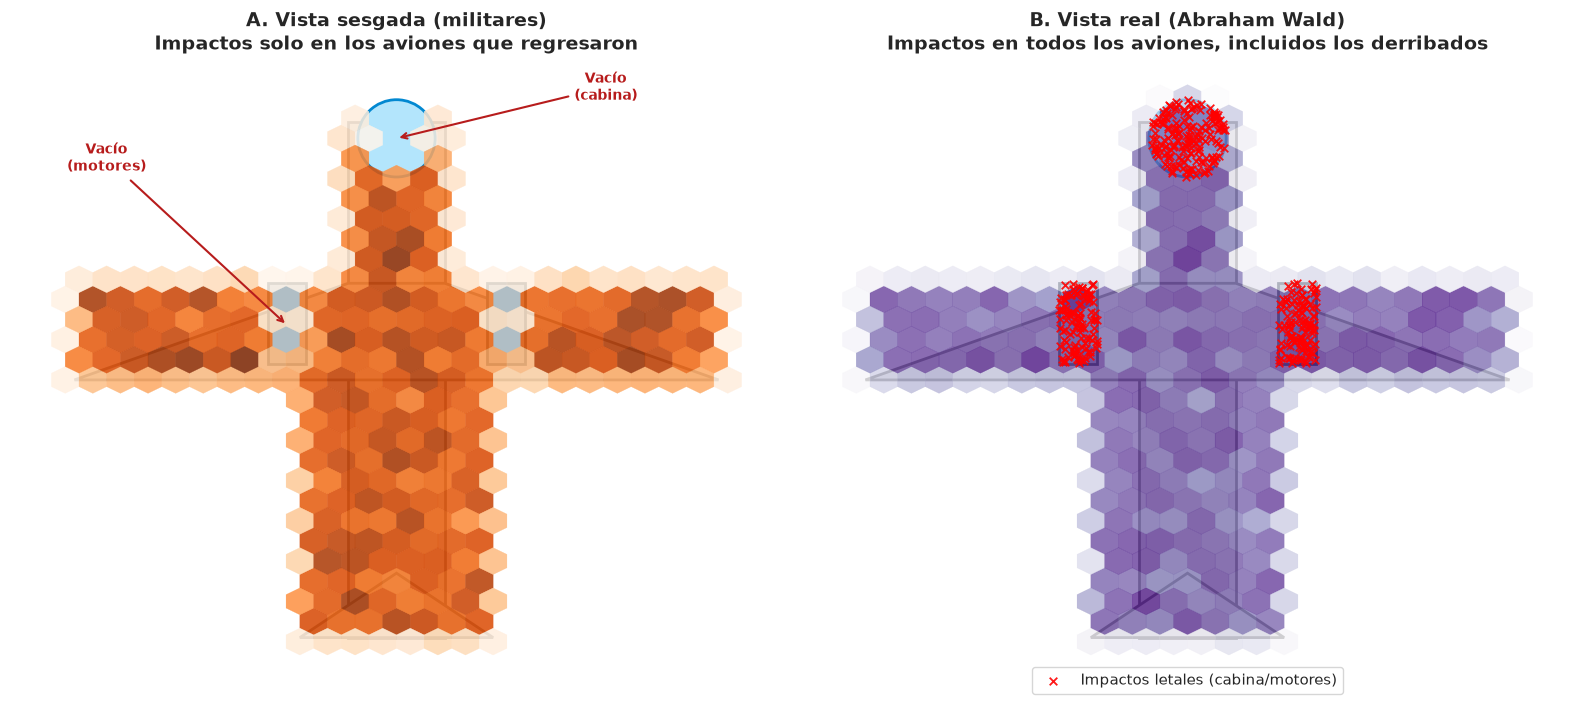

In [91]:
def plot_airplane_silhouette(ax):
    # Fuselaje
    fuselage = plt.Rectangle((-1.5, -8), 3, 16, color='#E0E0E0', ec='#757575', lw=2, zorder=1)
    ax.add_patch(fuselage)
    # Alas
    wings = plt.Polygon([[-10, 0], [10, 0], [1.5, 3], [-1.5, 3]], color='#E0E0E0', ec='#757575', lw=2, zorder=1)
    ax.add_patch(wings)
    # Cabina
    cockpit = plt.Circle((0, 7.5), 1.2, color='#B3E5FC', ec='#0288D1', lw=2, zorder=2)
    ax.add_patch(cockpit)
    # Motores
    engine_l = plt.Rectangle((-4, 0.5), 1.2, 2.5, color='#B0BEC5', ec='#37474F', lw=2, zorder=2)
    engine_r = plt.Rectangle((2.8, 0.5), 1.2, 2.5, color='#B0BEC5', ec='#37474F', lw=2, zorder=2)
    ax.add_patch(engine_l)
    ax.add_patch(engine_r)
    # Cola
    tail = plt.Polygon([[-3, -8], [3, -8], [0, -6]], color='#E0E0E0', ec='#757575', lw=2, zorder=1)
    ax.add_patch(tail)
    
    ax.set_xlim(-12, 12)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.axis('off')

# Mapa de densidad hexagonal (hexbin): deja ver los huecos de cabina/motores
extent = (-12, 12, -10, 10)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Gráfico A: Solo supervivientes (lo que observaron los militares) ---
plot_airplane_silhouette(axes[0])
supervivientes = df_impactos[df_impactos['sobrevive_avion'] == 1]
axes[0].hexbin(supervivientes['x'], supervivientes['y'], gridsize=28, cmap='Oranges',
               mincnt=1, extent=extent, alpha=0.85, zorder=3, linewidths=0.2)
# Señalamos los vacíos característicos del sesgo de supervivencia (0 impactos ahí)
axes[0].annotate('Vacío\n(cabina)', xy=(0, 7.5), xytext=(6.5, 8.7), fontsize=10, fontweight='bold',
                 color='#B71C1C', ha='center', zorder=5,
                 arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5))
axes[0].annotate('Vacío\n(motores)', xy=(-3.4, 1.7), xytext=(-9, 6.5), fontsize=10, fontweight='bold',
                 color='#B71C1C', ha='center', zorder=5,
                 arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.5))
axes[0].set_title("A. Vista sesgada (militares)\nImpactos solo en los aviones que regresaron", fontsize=14, fontweight='bold')

# --- Gráfico B: Realidad completa (Abraham Wald) ---
plot_airplane_silhouette(axes[1])
axes[1].hexbin(df_impactos['x'], df_impactos['y'], gridsize=28, cmap='Purples',
               mincnt=1, extent=extent, alpha=0.70, zorder=3, linewidths=0.2)
# X en los impactos realmente letales (cabina/motores) de los aviones derribados
letales = df_impactos[(df_impactos['sobrevive_avion'] == 0) & (df_impactos['zona'].isin(['Cabina', 'Motores']))]
axes[1].scatter(letales['x'].head(400), letales['y'].head(400), color='red', marker='x',
                s=30, lw=1.3, alpha=0.9, zorder=4, label='Impactos letales (cabina/motores)')
axes[1].set_title("B. Vista real (Abraham Wald)\nImpactos en todos los aviones, incluidos los derribados", fontsize=14, fontweight='bold')
axes[1].legend(loc='lower center')

plt.tight_layout()
plt.show()

### Análisis del Gráfico
- **En el Gráfico A (Militares):** El mapa de densidad de los aviones supervivientes muestra un **vacío absoluto** en la **cabina** y los **motores** (señalado con flechas): esas celdas quedan sin color porque en los datos ningún superviviente registró impactos ahí. Se recrea así el dibujo clásico del sesgo de supervivencia, donde el daño observado se concentra en alas y fuselaje.
- **En el Gráfico B (Real):** Los impactos del fuego antiaéreo ocurren de forma **uniforme** por toda la silueta (los disparos son aleatorios). Las **X rojas** marcan únicamente los impactos **letales** (los que cayeron en cabina o motores) de los aviones derribados; por eso se concentran exactamente en las dos zonas que aparecían vacías en el Gráfico A.
- **Conclusión de Wald:** hay que blindar precisamente donde los supervivientes **no** muestran daño (cabina y motores), no donde sí lo muestran.

## 3. Preprocesamiento, Escalado e Impacto del Sesgo en ML

Para garantizar que los modelos lineales como la Regresión Logística comparen sus variables de forma justa, aplicaremos **Escalado de Características (`StandardScaler`)**. Esto sitúa todas las variables en la misma escala (media 0 y desviación estándar 1).

Entrenaremos los modelos en dos situaciones:
1. **Dataset Real (Wald):** Contiene la información de supervivencia correcta de todas las misiones.
2. **Dataset Sesgado (Militar):** Simulamos que el analista militar extrapola las medias observadas en los supervivientes a los aviones caídos, asumiendo que la muestra que regresó es representativa.

Coeficientes aprendidos por cada modelo:
    Zona  Real (Wald)  Sesgado (Militar)
  Cabina       -4.376                0.0
 Motores       -5.252                0.0
    Alas        0.057                0.0
Fuselaje        0.061                0.0


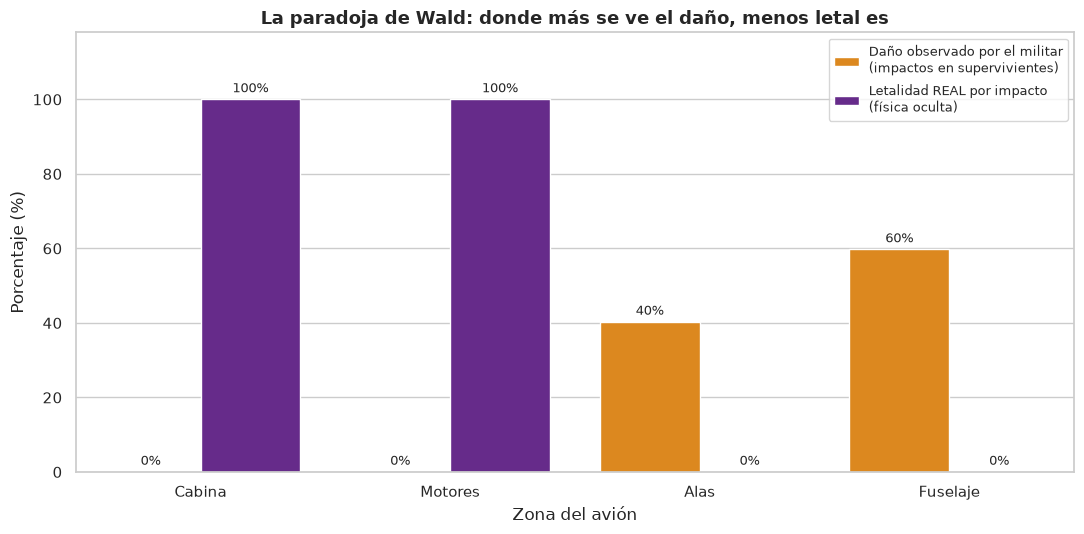

In [92]:
# Separar variables independientes y objetivo
X = df_aviones[['impactos_cabina', 'impactos_motores', 'impactos_alas', 'impactos_fuselaje']]
y = df_aviones['sobreviviente']

# Partición Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado de Características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo real (Wald)
model_real = LogisticRegression()
model_real.fit(X_train_scaled, y_train)

# Modelo sesgado (militar)
X_militar = X_train.copy().astype(float)
y_militar = y_train.copy()

# El militar asume que los caídos tienen los mismos patrones de impactos que los supervivientes:
# copia el perfil medio de los supervivientes a todos los aviones derribados.
survivors_idx = y_train[y_train == 1].index
downed_idx = y_train[y_train == 0].index
X_militar.loc[downed_idx] = X_train.loc[survivors_idx].mean().values

scaler_militar = StandardScaler()
X_militar_scaled = scaler_militar.fit_transform(X_militar)
model_militar = LogisticRegression()
model_militar.fit(X_militar_scaled, y_militar)

# Tabla de coeficientes (evidencia numérica del colapso del modelo sesgado)
df_coef = pd.DataFrame({
    'Zona': ['Cabina', 'Motores', 'Alas', 'Fuselaje'],
    'Real (Wald)': np.round(model_real.coef_[0], 3) + 0.0,
    'Sesgado (Militar)': np.round(model_militar.coef_[0], 3) + 0.0
})
print("Coeficientes aprendidos por cada modelo:")
print(df_coef.to_string(index=False))

# Gráfica: la inversión del sesgo de supervivencia. Comparamos lo que el
# militar observa (impactos en supervivientes) contra la letalidad real de
# cada zona (la física oculta de la simulación).
zonas = ['Cabina', 'Motores', 'Alas', 'Fuselaje']

# % de impactos que el militar ve, mirando solo a los aviones que regresaron
imp_sup = df_impactos[df_impactos['sobrevive_avion'] == 1]['zona'].value_counts().reindex(zonas, fill_value=0)
obs_pct = (imp_sup / imp_sup.sum() * 100).values

# Letalidad real por impacto en cada zona (probabilidad de derribo definida en la simulación)
letal_real = np.array([100.0, 100.0, 0.0, 0.0])

comp = pd.DataFrame({
    'Zona': zonas,
    'Daño observado por el militar\n(impactos en supervivientes)': obs_pct,
    'Letalidad REAL por impacto\n(física oculta)': letal_real
})
comp_m = comp.melt(id_vars='Zona', var_name='Perspectiva', value_name='Porcentaje')

plt.figure(figsize=(11, 5.5))
ax = sns.barplot(data=comp_m, x='Zona', y='Porcentaje', hue='Perspectiva',
                 palette=['#FB8C00', '#6A1B9A'])
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.0f%%', fontsize=9, padding=3)
ax.set_ylim(0, 118)
plt.title('La paradoja de Wald: donde más se ve el daño, menos letal es',
          fontsize=13, fontweight='bold')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Zona del avión')
plt.legend(loc='upper right', ncol=1, fontsize=9)
plt.tight_layout()
plt.show()

### Interpretación del ML bajo Sesgo
- **Modelo de Wald (Real):** los coeficientes de **Cabina** y **Motores** son fuertemente negativos (≈ -4.4 y -5.3). El clasificador aprende correctamente que un impacto en esas zonas hunde la probabilidad de sobrevivir. **Alas** y **Fuselaje** quedan cerca de 0: son prácticamente inofensivas.
- **Modelo Militar (Sesgado):** al asumir que los aviones caídos eran iguales a los supervivientes, las columnas de Cabina y Motores quedan **constantes** (ningún superviviente registra impactos ahí). Sin varianza, el modelo no puede aprender su letalidad y **todos los coeficientes colapsan a ≈ 0**. 
- **Lección clave:** el sesgo de supervivencia no solo distorsiona la señal, **la elimina**. El modelo se vuelve completamente ciego justo a las zonas mortales, exactamente el error histórico que Wald corrigió, y ningún algoritmo (por potente que sea) puede recuperar una información que nunca estuvo en los datos.

### La consecuencia práctica del sesgo

Toda la paradoja se resume en **dónde decides poner el blindaje**. Con exactamente los mismos aviones observados, dos analistas llegan a conclusiones opuestas: el militar refuerza las alas y el fuselaje (donde ve agujeros, pero que son inofensivos), mientras que Wald refuerza la cabina y los motores (donde no ve agujeros… porque esos aviones nunca regresaron).

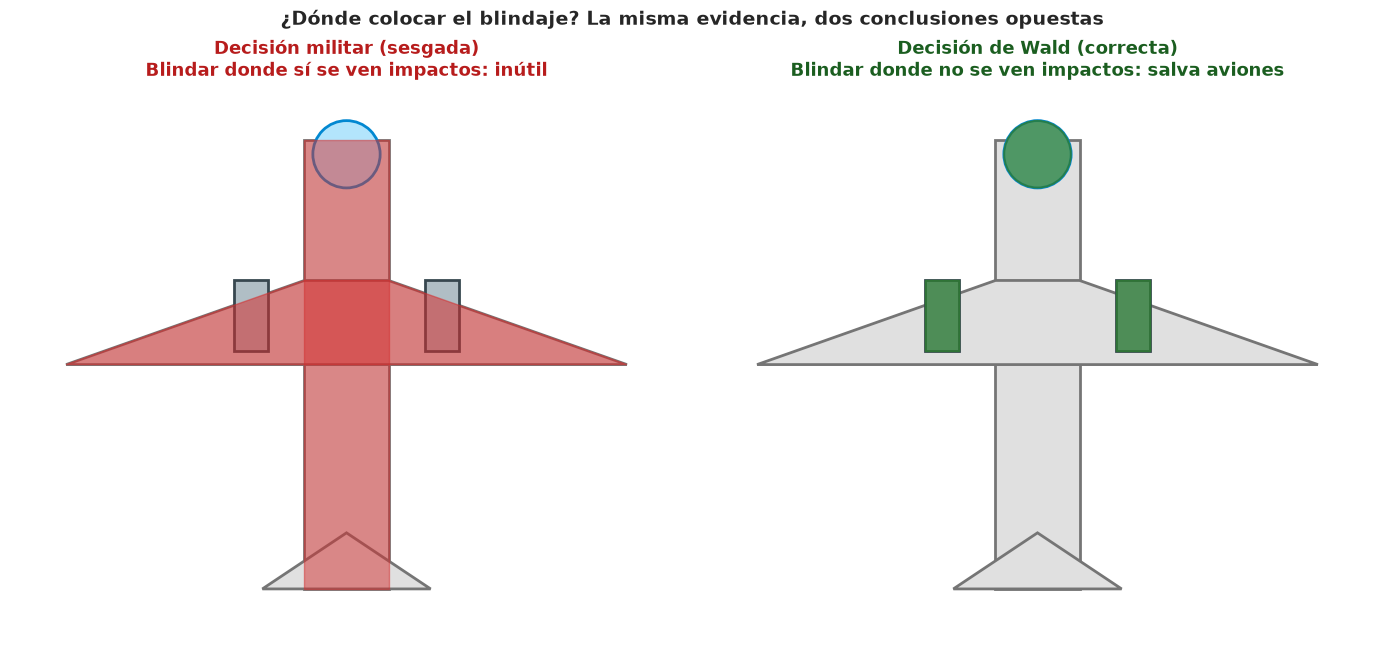

In [93]:
# ¿Dónde habría que blindar el avión?
# Izquierda: la decisión sesgada (blindar donde se ven impactos), que es inútil.
# Derecha: la decisión de Wald (blindar donde no se ven), que es la correcta.
def marcar_blindaje(ax, zonas):
    if 'alas' in zonas:
        ax.add_patch(plt.Polygon([[-10, 0], [10, 0], [1.5, 3], [-1.5, 3]],
                                 color=zonas['alas'], alpha=0.55, zorder=4))
    if 'fuselaje' in zonas:
        ax.add_patch(plt.Rectangle((-1.5, -8), 3, 16, color=zonas['fuselaje'], alpha=0.50, zorder=4))
    if 'cabina' in zonas:
        ax.add_patch(plt.Circle((0, 7.5), 1.2, color=zonas['cabina'], alpha=0.75, zorder=4))
    if 'motores' in zonas:
        ax.add_patch(plt.Rectangle((-4, 0.5), 1.2, 2.5, color=zonas['motores'], alpha=0.75, zorder=4))
        ax.add_patch(plt.Rectangle((2.8, 0.5), 1.2, 2.5, color=zonas['motores'], alpha=0.75, zorder=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Izquierda: decisión militar sesgada, blinda alas y fuselaje (donde se ven impactos)
plot_airplane_silhouette(axes[0])
marcar_blindaje(axes[0], {'alas': '#D32F2F', 'fuselaje': '#D32F2F'})
axes[0].set_title("Decisión militar (sesgada)\nBlindar donde sí se ven impactos: inútil",
                  fontsize=13, fontweight='bold', color='#B71C1C')

# Derecha: decisión de Wald, blinda cabina y motores (donde no se ven impactos)
plot_airplane_silhouette(axes[1])
marcar_blindaje(axes[1], {'cabina': '#2E7D32', 'motores': '#2E7D32'})
axes[1].set_title("Decisión de Wald (correcta)\nBlindar donde no se ven impactos: salva aviones",
                  fontsize=13, fontweight='bold', color='#1B5E20')

fig.suptitle("¿Dónde colocar el blindaje? La misma evidencia, dos conclusiones opuestas",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# PARTE 2: Modelado y Predicción de Defensa Aérea en Ucrania con Datos Reales

En esta sección utilizaremos datos reales del conflicto para construir un pipeline de Machine Learning completo y optimizado. El objetivo es predecir si un proyectil (misil o drone) será **interceptado exitosamente** (`1`) o si **evade las defensas** (`0`).

### Fases del Proyecto de ML Implementadas:
0.  **Exploración del Dataset (EDA):** Descripción del dato crudo, calidad (nulos) y contexto temporal antes de intervenirlo.
1.  **Limpieza y Fusión de Datos:** Carga y merge de la base de ataques y taxonomía de armas.
2.  **Imputación e Inferencia de Datos:** Corrección de valores nulos e inconsistencias.
3.  **Tratamiento de Outliers (Valores Atípicos):** Análisis de valores extremos en la variable de saturación.
4.  **Ingeniería de Características:** Extracción de componentes de tiempo, zonas geográficas de destino y la variable operativa de Defensas Modernas (Patriot).
5.  **Codificación y Escalado:** One-Hot Encoding de columnas de texto y escalado de variables numéricas.
6.  **Ajuste de Hiperparámetros (Grid Search con CV):** Optimización fina del modelo Random Forest y XGBoost.
7.  **Análisis Comparativo y Evaluación Avanzada:** Curvas ROC/AUC y matrices de confusión graficadas.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
from xgboost import XGBClassifier

# Cargar datasets reales descargados
df_attacks = pd.read_csv("missile_attacks_daily.csv")
df_taxonomy = pd.read_csv("missiles_and_uavs.csv")

print(f"Datos de ataques: {df_attacks.shape}")
print(f"Datos de taxonomía: {df_taxonomy.shape}")

Datos de ataques: (3835, 22)
Datos de taxonomía: (64, 12)


## 0. Fase 0 - Exploración Inicial del Dataset (EDA)

Antes de limpiar hay que **entender qué tenemos**. Este análisis exploratorio (EDA,
del módulo de Visualización) describe el dato **crudo** y **justifica** cada decisión de
limpieza posterior: no se interviene un dataset que no se ha mirado.

**¿Qué son estos datos?** Registros públicos de los ataques aéreos rusos sobre Ucrania
(misiles y drones). Trabajamos con dos archivos:

- `missile_attacks_daily.csv`: **3.835 registros y 22 columnas**. Cada fila es un
  **episodio de ataque** (un tipo de arma en una fecha), con cuántas unidades se
  **lanzaron** (`launched`) y cuántas se **derribaron** (`destroyed`). *No es un
  proyectil por fila*: eso lo construiremos en la Fase 4 (desenrollado).
- `missiles_and_uavs.csv`: **64 modelos y 12 columnas**, la **taxonomía** que asigna a
  cada modelo su `category` (UAV, misil crucero, balístico, etc.).

**Ventana temporal:** del **28-sep-2022** al **27-jun-2026**.

**Variable objetivo (se define más adelante):** `interceptado` = `destroyed / launched`.

Miramos tres cosas: **estructura**, **calidad del dato** (nulos) y **dos vistas
exploratorias** que enmarcan todo el análisis (la escalada del conflicto y la carencia
de datos en muchas columnas).

In [95]:
df_attacks.head()

,time_start,time_end,model,launch_place,target,target_main,launched,destroyed,not_reach_goal,still_attacking,...,num_hit_location,num_fall_fragment_location,carrier,turbojet,turbojet_destroyed,affected region,destroyed_details,launched_details,launch_place_details,source
0,2026-06-27 18:00,2026-06-28 08:30,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Oryol ...,Ukraine,NaN,142.0,125.0,0.0,3.0,...,11.0,13.0,NaN,NaN,NaN,NaN,"{'south': 23, 'east': NaN, 'north': NaN}",NaN,NaN,kpszsu/posts/pfbid0iDCbW761TQfPkvVMVghQQ3ADuiz...
1,2026-06-27 18:00,2026-06-28 08:30,C-400 and Iskander-M,Bryansk oblast,Ukraine,NaN,6.0,6.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid0iDCbW761TQfPkvVMVghQQ3ADuiz...
2,2026-06-27 18:00,2026-06-28 08:30,3M22 Zircon,Kursk oblast,Ukraine,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,kpszsu/posts/pfbid0iDCbW761TQfPkvVMVghQQ3ADuiz...
3,2026-06-26 18:00,2026-06-27 08:30,Shahed-136/131,Primorsko-Akhtarsk and Kursk oblast and Bryans...,Ukraine,NaN,129.0,113.0,0.0,3.0,...,7.0,3.0,NaN,NaN,NaN,NaN,"{'south': 8, 'west': 1, 'east': NaN, 'north': ...",NaN,NaN,kpszsu/posts/pfbid02eJ3Nvs4RLVE6pigzMZVYeWXyNG...
4,2026-06-27,2026-06-27,X-59,Black Sea,south,NaN,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PvKPivden/posts/pfbid0bUSspxePkJ9xri4yp9NqJPrg...


In [96]:
df_attacks.describe()

,launched,destroyed,not_reach_goal,still_attacking,is_shahed,num_hit_location,num_fall_fragment_location,turbojet,turbojet_destroyed
count,3832.000000,3829.000000,723.000000,233.000000,239.000000,403.000000,386.000000,3.000000,3.000000
mean,32.226514,24.708279,18.071923,3.240343,108.422594,11.334988,4.937824,7.333333,7.000000
std,76.811976,64.075006,35.780654,4.534609,78.166820,6.373487,6.039805,3.055050,3.605551
min,1.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,4.000000,3.000000
25%,1.000000,1.000000,0.000000,1.000000,60.000000,7.000000,1.000000,6.000000,5.500000
50%,4.000000,2.000000,1.000000,2.000000,80.000000,10.000000,3.000000,8.000000,8.000000
75%,23.000000,19.000000,25.000000,4.000000,120.000000,14.000000,7.000000,9.000000,9.000000
max,810.000000,747.000000,415.000000,46.000000,400.000000,54.000000,44.000000,10.000000,10.000000


In [97]:
df_attacks.info()

<class 'pandas.DataFrame'>
RangeIndex: 3835 entries, 0 to 3834
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   time_start                  3835 non-null   str    
 1   time_end                    3835 non-null   str    
 2   model                       3835 non-null   str    
 3   launch_place                2008 non-null   str    
 4   target                      3805 non-null   str    
 5   target_main                 64 non-null     str    
 6   launched                    3832 non-null   float64
 7   destroyed                   3829 non-null   float64
 8   not_reach_goal              723 non-null    float64
 9   still_attacking             233 non-null    float64
 10  border_crossing             3835 non-null   str    
 11  is_shahed                   239 non-null    float64
 12  num_hit_location            403 non-null    float64
 13  num_fall_fragment_location  386 non-null    

In [98]:
df_taxonomy.head()

,model,category,national_origin,type,launch_platform,name,name_NATO,in_sevice,designer,manufacturer,guidance_system,unit_cost
0,Eleron,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,ENICS,NaN,NaN
1,Forpost,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ural Works of Civil Aviation,NaN,NaN
2,Granat-4,UAV,russia,reconnaissance,NaN,NaN,NaN,NaN,NaN,Ижмаш – беспилотные системы,NaN,NaN
3,Kub,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN
4,Lancet,UAV,russia,loitering munition,NaN,NaN,NaN,NaN,NaN,ZALA Aero Group,NaN,NaN


In [99]:
df_taxonomy.describe()

,in_sevice
count,9.000000
mean,2008.222222
std,17.746674
min,1978.000000
25%,2006.000000
50%,2017.000000
75%,2021.000000
max,2024.000000


In [100]:
df_taxonomy.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            64 non-null     str    
 1   category         64 non-null     str    
 2   national_origin  61 non-null     str    
 3   type             36 non-null     str    
 4   launch_platform  17 non-null     str    
 5   name             20 non-null     str    
 6   name_NATO        15 non-null     str    
 7   in_sevice        9 non-null      float64
 8   designer         4 non-null      str    
 9   manufacturer     23 non-null     str    
 10  guidance_system  2 non-null      str    
 11  unit_cost        1 non-null      str    
dtypes: float64(1), str(11)
memory usage: 6.1 KB


In [101]:
# Estructura y calidad del dato crudo (aún sin limpiar)
print(f"Registros de ataques: {df_attacks.shape[0]} filas x {df_attacks.shape[1]} columnas")
print(f"Taxonomía de armas:   {df_taxonomy.shape[0]} modelos x {df_taxonomy.shape[1]} columnas")

# Rango temporal (parseo LOCAL con format='mixed'; no modificamos df_attacks aquí)
_fechas = pd.to_datetime(df_attacks['time_start'], format='mixed', errors='coerce')
print(f"Ventana temporal: {_fechas.min().date()} a {_fechas.max().date()}")

# Tipos y % de nulos por columna: revela qué es usable y qué está casi vacío
resumen = pd.DataFrame({
    'dtype': df_attacks.dtypes.astype(str),
    'nulos_%': (df_attacks.isna().mean() * 100).round(1)
}).sort_values('nulos_%', ascending=False)
print("\nColumnas por % de nulos (por esto hace falta la fase de limpieza):")
print(resumen.to_string())

print("\nDistribución de 'launched' (unidades lanzadas por episodio):")
print(df_attacks['launched'].describe().round(1).to_string())
print("Muy sesgada a la derecha (mediana 4, media 32, máx 810): habrá que revisar outliers en la Fase 3.")

# Vistazo a las columnas que sí vamos a usar
df_attacks[['time_start', 'model', 'launched', 'destroyed', 'target']].head()


Registros de ataques: 3835 filas x 22 columnas
Taxonomía de armas:   64 modelos x 12 columnas
Ventana temporal: 2022-09-28 a 2026-06-27

Columnas por % de nulos (por esto hace falta la fase de limpieza):
                              dtype  nulos_%
turbojet                    float64     99.9
turbojet_destroyed          float64     99.9
launch_place_details            str     99.8
launched_details                str     99.8
target_main                     str     98.3
affected region                 str     94.4
still_attacking             float64     93.9
is_shahed                   float64     93.8
carrier                         str     91.9
num_fall_fragment_location  float64     89.9
num_hit_location            float64     89.5
not_reach_goal              float64     81.1
destroyed_details               str     77.3
launch_place                    str     47.6
target                          str      0.8
destroyed                   float64      0.2
launched                    flo

,time_start,model,launched,destroyed,target
0,2026-06-27 18:00,Shahed-136/131,142.0,125.0,Ukraine
1,2026-06-27 18:00,C-400 and Iskander-M,6.0,6.0,Ukraine
2,2026-06-27 18:00,3M22 Zircon,1.0,1.0,Ukraine
3,2026-06-26 18:00,Shahed-136/131,129.0,113.0,Ukraine
4,2026-06-27,X-59,1.0,1.0,south


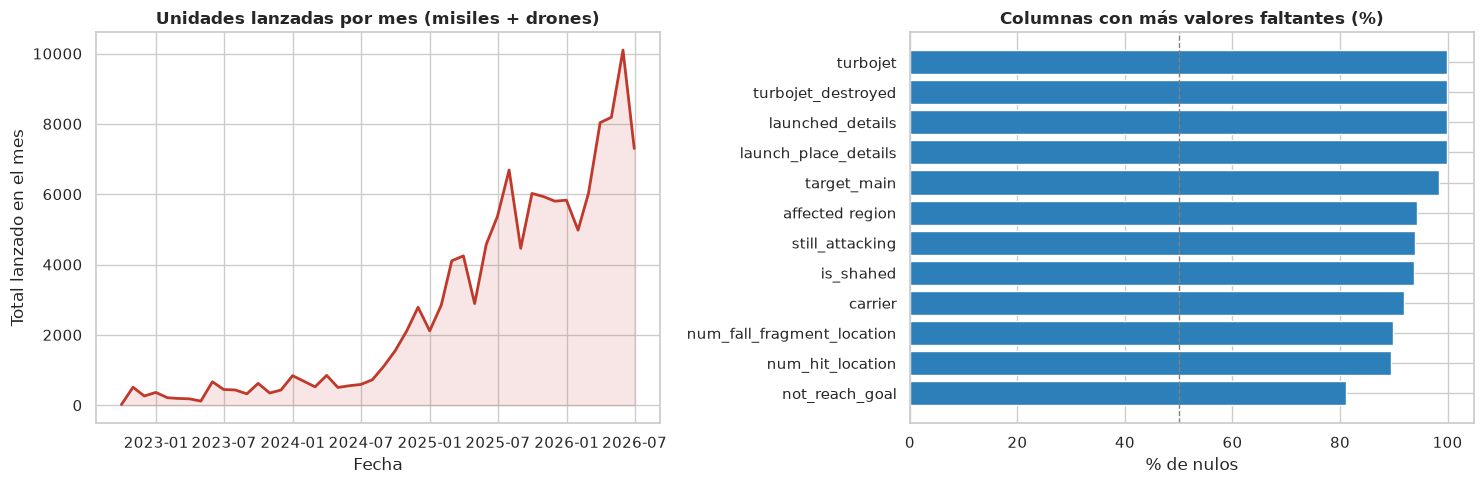

Meses cubiertos: 46 | pico mensual: 10098 unidades en May-2026
(a) El volumen de ataques crece con el tiempo; eso explica luego el efecto confundido
de 'defensa_moderna' (más defensa moderna coincide con más saturación).
(b) Muchas columnas están casi vacías (turbojet, is_shahed...), así que nos quedamos
con las pocas columnas usables: time_start, model, launched, destroyed y target.


In [102]:
# Dos vistas exploratorias que enmarcan el análisis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Volumen lanzado por mes: muestra la escalada del conflicto
serie = pd.DataFrame({
    'fecha': pd.to_datetime(df_attacks['time_start'], format='mixed', errors='coerce'),
    'launched': df_attacks['launched']
}).dropna()
por_mes = serie.set_index('fecha').resample('ME')['launched'].sum()
axes[0].plot(por_mes.index, por_mes.values, color='#c0392b', lw=2)
axes[0].fill_between(por_mes.index, por_mes.values, color='#c0392b', alpha=0.12)
axes[0].set_title('Unidades lanzadas por mes (misiles + drones)', fontweight='bold')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Total lanzado en el mes')

# (b) Calidad del dato: % de nulos por columna (top 12), motiva la limpieza
nulos = (df_attacks.isna().mean() * 100).sort_values(ascending=False).head(12)
axes[1].barh(nulos.index[::-1], nulos.values[::-1], color='#2c7fb8')
axes[1].axvline(50, color='gray', ls='--', lw=1)
axes[1].set_title('Columnas con más valores faltantes (%)', fontweight='bold')
axes[1].set_xlabel('% de nulos')

plt.tight_layout()
plt.show()

print(f"Meses cubiertos: {len(por_mes)} | pico mensual: {por_mes.max():.0f} unidades "
      f"en {por_mes.idxmax().strftime('%b-%Y')}")
print("(a) El volumen de ataques crece con el tiempo; eso explica luego el efecto confundido")
print("de 'defensa_moderna' (más defensa moderna coincide con más saturación).")
print("(b) Muchas columnas están casi vacías (turbojet, is_shahed...), así que nos quedamos")
print("con las pocas columnas usables: time_start, model, launched, destroyed y target.")


## 1. Fase de Limpieza, Tratamiento de Nulos y Fusión

In [103]:
# Limpieza de nulos críticos en la variable predictora principal 'launched'
df_attacks = df_attacks.dropna(subset=['launched'])
df_attacks = df_attacks[df_attacks['launched'] > 0]

# Imputación de nulos en la variable objetivo agregada 'destroyed' (asumimos 0 si no se reporta destrucción)
df_attacks['destroyed'] = df_attacks['destroyed'].fillna(0)

# Asegurar consistencia lógica
df_attacks['destroyed'] = np.minimum(df_attacks['launched'], df_attacks['destroyed'])

# Fusionar datasets
df_merged = pd.merge(df_attacks, df_taxonomy[['model', 'category']], on='model', how='left')

# Función de imputación de categorías faltantes (para garantizar que no existan NAs en la taxonomía)
def inferir_categoria(row):
    if not pd.isna(row['category']):
        return row['category']
    model_str = str(row['model']).lower()
    if any(x in model_str for x in ['shahed', 'uav', 'drone', 'orlan', 'lancet', 'supercam', 'zala', 'молнія', 'eleron', 'forpost']):
        return 'UAV'
    elif any(x in model_str for x in ['iskander', 'kinzhal', 'zircon', 'ballistic', 'kn-23']):
        return 'ballistic missile'
    elif any(x in model_str for x in ['c-300', 'c-400', 's-300', 's-400', 'surface-to-air']):
        return 'surface-to-air missile'
    elif any(x in model_str for x in ['kalibr', 'x-101', 'x-59', 'x-22', 'x-35', 'x-31', 'cruise']):
        return 'cruise missile'
    else:
        return 'cruise missile'

df_merged['category'] = df_merged.apply(inferir_categoria, axis=1)
print(df_merged['category'].value_counts())

category
UAV                             2495
cruise missile                   730
ballistic missile                466
surface-to-air missile           110
surface-to-air and ballistic      26
guided bomb                        5
Name: count, dtype: int64


## 2. Fase de Ingeniería de Características (Feature Engineering) e Historial Temporal

In [104]:
# A. Convertir fechas y extraer componentes de tiempo
# Nota: 'time_start' viene en dos formatos ('YYYY-MM-DD HH:MM:SS' y 'YYYY-MM-DD' sin hora).
# Con el parseo por defecto, pandas infiere un solo formato y convierte a NaT el otro,
# descartando ~2.266 filas (los ataques más recientes). Con format='mixed' no perdemos datos.
df_merged['time_start'] = pd.to_datetime(df_merged['time_start'], format='mixed', errors='coerce')
n_antes = len(df_merged)
df_merged = df_merged.dropna(subset=['time_start'])
print(f"Filas con fecha válida: {len(df_merged)} de {n_antes} (descartadas: {n_antes - len(df_merged)})")
df_merged['date'] = df_merged['time_start'].dt.date
df_merged['mes'] = df_merged['time_start'].dt.month
# Codificación cíclica del mes: dic (12) está pegado a ene (1), pero como número lineal el
# modelo los cree a 11 de distancia. Seno/coseno preservan esa continuidad circular.
df_merged['mes_sin'] = np.sin(2 * np.pi * df_merged['mes'] / 12)
df_merged['mes_cos'] = np.cos(2 * np.pi * df_merged['mes'] / 12)

# B. Defensas Modernas (Patriot): Activa a partir del 1 de mayo de 2023
df_merged['defensa_moderna'] = df_merged['time_start'].apply(lambda x: 1 if x >= pd.Timestamp('2023-05-01') else 0)

# C. Saturación Diaria (Volumen total de amenazas en el aire ese día)
sat_map = df_merged.groupby('date')['launched'].sum().to_dict()
df_merged['saturacion_dia'] = df_merged['date'].map(sat_map)

# D. Mapeo regional del objetivo de ataque (Target)
def mapear_region(target_str):
    if pd.isna(target_str):
        return 'General/Multi'
    t = str(target_str).lower()
    if 'kyiv' in t or 'kiev' in t:
        return 'Norte/Capital'
    elif any(x in t for x in ['odesa', 'south', 'mykolaiv', 'kherson', 'crimea', 'zaporizhzhia']):
        return 'Sur'
    elif any(x in t for x in ['kharkiv', 'east', 'dnipro', 'donetsk', 'luhansk']):
        return 'Este'
    elif any(x in t for x in ['lviv', 'west', 'khmelnytskyi', 'zakarpattia']):
        return 'Oeste'
    else:
        return 'General/Multi'

df_merged['region_objetivo'] = df_merged['target'].apply(mapear_region)
df_merged[['time_start', 'category', 'saturacion_dia', 'defensa_moderna', 'region_objetivo']].head()

Filas con fecha válida: 3832 de 3832 (descartadas: 0)


,time_start,category,saturacion_dia,defensa_moderna,region_objetivo
0,2026-06-27 18:00:00,UAV,193.0,1,General/Multi
1,2026-06-27 18:00:00,surface-to-air and ballistic,193.0,1,General/Multi
2,2026-06-27 18:00:00,cruise missile,193.0,1,General/Multi
3,2026-06-26 18:00:00,UAV,189.0,1,General/Multi
4,2026-06-27 00:00:00,cruise missile,193.0,1,Sur


## 3. Detección y Tratamiento de Outliers (Valores Atípicos)

Analizaremos los valores extremos en la variable `saturacion_dia` (días con una cantidad anormalmente grande de ataques aéreos coordinados).

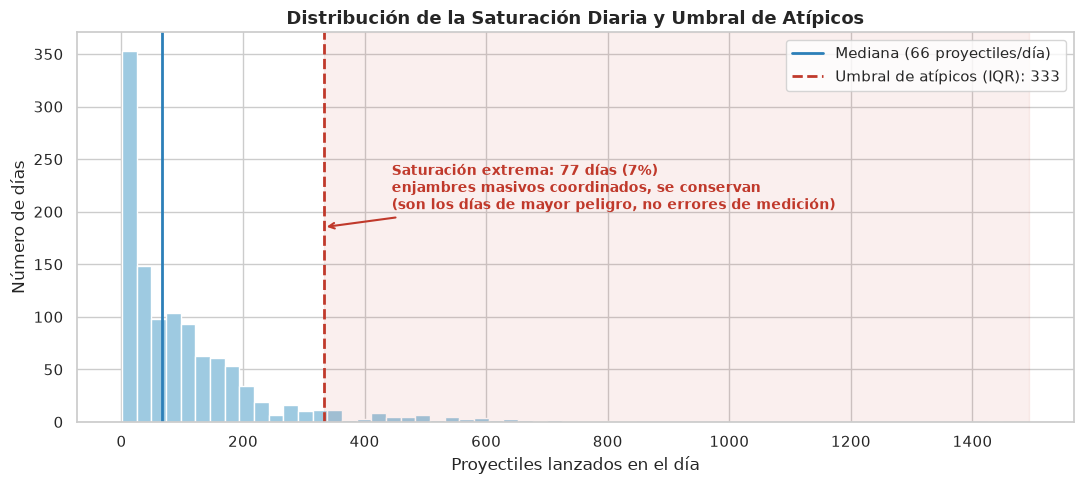

Q1=18, Q3=144, IQR=126 | Umbral atípicos: 333 lanzamientos/día
Días de saturación extrema: 77 de 1142 (6.7%)


In [105]:
# Saturación diaria: una fila por día (no por proyectil, que sobre-pondera los días con
# muchos tipos de arma). Buscamos días de saturación anormalmente alta (enjambres masivos).
sat_por_dia = df_merged.drop_duplicates('date').set_index('date')['saturacion_dia']

Q1, Q3 = sat_por_dia.quantile(0.25), sat_por_dia.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
n_out = int((sat_por_dia > limite_superior).sum())

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sat_por_dia, bins=60, color='#9ecae1', edgecolor='white')
ax.axvline(sat_por_dia.median(), color='#2c7fb8', lw=2,
           label=f'Mediana ({sat_por_dia.median():.0f} proyectiles/día)')
ax.axvline(limite_superior, color='#c0392b', lw=2, ls='--',
           label=f'Umbral de atípicos (IQR): {limite_superior:.0f}')
ax.axvspan(limite_superior, sat_por_dia.max() * 1.03, color='#c0392b', alpha=0.08)

ymax = ax.get_ylim()[1]
ax.annotate(f'Saturación extrema: {n_out} días ({n_out/len(sat_por_dia):.0%})\n'
            'enjambres masivos coordinados, se conservan\n'
            '(son los días de mayor peligro, no errores de medición)',
            xy=(limite_superior, ymax * 0.5),
            xytext=(limite_superior + (sat_por_dia.max() - limite_superior) * 0.10, ymax * 0.6),
            fontsize=10, color='#c0392b', fontweight='bold', va='center',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))

ax.set_title('Distribución de la Saturación Diaria y Umbral de Atípicos',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Proyectiles lanzados en el día')
ax.set_ylabel('Número de días')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f} | Umbral atípicos: {limite_superior:.0f} lanzamientos/día")
print(f"Días de saturación extrema: {n_out} de {len(sat_por_dia)} ({n_out/len(sat_por_dia):.1%})")

# Decisión de diseño: no se eliminan estos atípicos. Corresponden a las oleadas de ataques
# aéreos rusos más masivas de la guerra (p. ej. los bombardeos masivos de invierno).
# Eliminarlos sesgaría el modelo y omitiría precisamente los momentos de mayor peligro táctico.


### Chequeo visual (Unidad 7): ¿cómo cambió el *volumen* de ataque con la defensa moderna?

Cruzamos una variable **numérica** (`saturacion_dia`) con una **categórica/binaria**
(`defensa_moderna`) mediante un **gráfico de violín** (técnica de visualización
categórica + numérica del temario). Igual que en el histograma, se usa **un dato por día**
para no sobre-ponderar los días con muchos tipos de arma.

Ojo con la interpretación: `defensa_moderna` es en realidad un **corte temporal**
(antes / después de may-2023, cuando llegaron los Patriot). El gráfico revela que **los
dos periodos no son comparables en volumen**: en el periodo "moderno" los ataques son
mucho más intensos. Es decir, la variable **mezcla** dos cosas (la llegada de los Patriot
y la escalada de la guerra), y ese *confundido* es justo la razón por la que no puede
leerse como "el efecto de la defensa moderna".

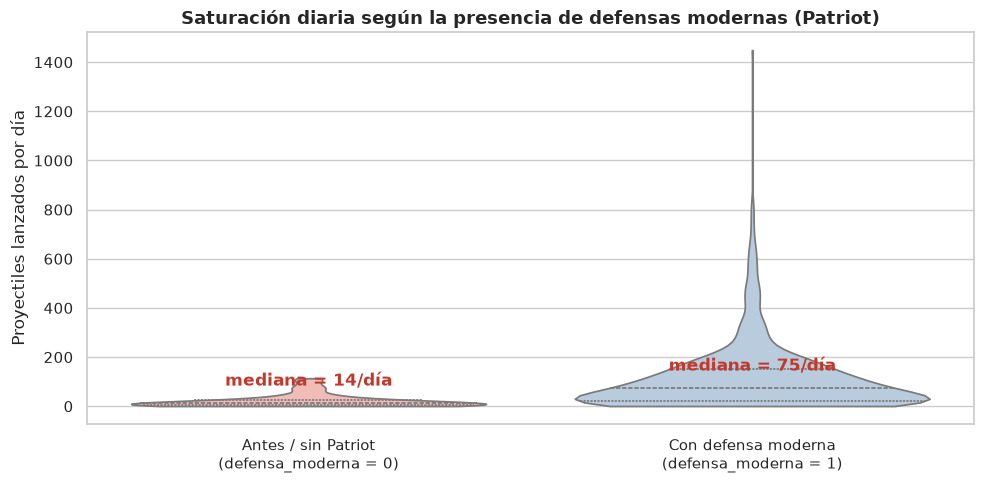

Mediana saturación/día, sin defensa moderna: 14 | con defensa moderna: 75  (x5.4)
Los dos periodos no son comparables en volumen: la mediana se multiplica por
~5. 'defensa_moderna' es un corte temporal (antes/después de may-2023) y en
ese lapso la guerra escaló, así que 'más defensa moderna' coincide con 'más saturación'.
Por eso la variable no mide el efecto de los Patriot: pese a ~5x más volumen de
ataque, la tasa de intercepción global casi no cambió (77.1% vs 76.6%).


In [106]:
# Cruce categórica + numérica (Unidad 7): saturación diaria vs. defensa moderna.
# Datos por día (drop_duplicates('date')) para no sobre-ponderar los días con varias armas.
sat_dia = df_merged.drop_duplicates('date')[['saturacion_dia', 'defensa_moderna']].copy()

med0 = sat_dia.loc[sat_dia['defensa_moderna'] == 0, 'saturacion_dia'].median()
med1 = sat_dia.loc[sat_dia['defensa_moderna'] == 1, 'saturacion_dia'].median()

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(x='defensa_moderna', y='saturacion_dia', data=sat_dia,
               hue='defensa_moderna', legend=False, palette='Pastel1',
               inner='quartile', cut=0, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Antes / sin Patriot\n(defensa_moderna = 0)',
                    'Con defensa moderna\n(defensa_moderna = 1)'])
ax.set_title('Saturación diaria según la presencia de defensas modernas (Patriot)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proyectiles lanzados por día')
ax.annotate(f'mediana = {med0:.0f}/día', xy=(0, med0), xytext=(0, med0 + 70),
            ha='center', color='#c0392b', fontweight='bold')
ax.annotate(f'mediana = {med1:.0f}/día', xy=(1, med1), xytext=(1, med1 + 70),
            ha='center', color='#c0392b', fontweight='bold')
plt.tight_layout()
plt.show()

ratio = med1 / med0 if med0 else float('nan')
print(f"Mediana saturación/día, sin defensa moderna: {med0:.0f} | con defensa moderna: {med1:.0f}"
      f"  (x{ratio:.1f})")
print("Los dos periodos no son comparables en volumen: la mediana se multiplica por")
print(f"~{ratio:.0f}. 'defensa_moderna' es un corte temporal (antes/después de may-2023) y en")
print("ese lapso la guerra escaló, así que 'más defensa moderna' coincide con 'más saturación'.")
print("Por eso la variable no mide el efecto de los Patriot: pese a ~5x más volumen de")
print("ataque, la tasa de intercepción global casi no cambió (77.1% vs 76.6%).")


## 4. Desenrollado de Registros a Proyectiles Individuales

Transformamos los datos diarios agrupados a nivel de fila individual para cada proyectil lanzado.

In [107]:
rows = []
for _, row in df_merged.iterrows():
    l = int(row['launched'])
    d = int(row['destroyed'])
    
    if l <= 0: 
        continue
    if d > l:
        d = l
        
    # Interceptados (1)
    for _ in range(d):
        rows.append({
            'category': row['category'],
            'saturacion_dia': row['saturacion_dia'],
            'defensa_moderna': row['defensa_moderna'],
            'region_objetivo': row['region_objetivo'],
            'mes_sin': row['mes_sin'],
            'mes_cos': row['mes_cos'],
            'date': row['date'],   # Se conserva el día para usarlo como grupo en la partición
            'interceptado': 1
        })
    # No interceptados (0)
    for _ in range(l - d):
        rows.append({
            'category': row['category'],
            'saturacion_dia': row['saturacion_dia'],
            'defensa_moderna': row['defensa_moderna'],
            'region_objetivo': row['region_objetivo'],
            'mes_sin': row['mes_sin'],
            'mes_cos': row['mes_cos'],
            'date': row['date'],   # Se conserva el día para usarlo como grupo en la partición
            'interceptado': 0
        })

df_individual = pd.DataFrame(rows)
print(f"Filas de datos individuales: {len(df_individual)}")
print(f"Tasa real de interceptación global: {df_individual['interceptado'].mean():.2%}")

Filas de datos individuales: 123492
Tasa real de interceptación global: 76.61%


## 5. Codificación, Escalado de Variables y Partición de Datos (Por Grupos)

Aquí prevenimos **dos** tipos de fuga de datos (*data leakage*):

1. **Fuga por escalado:** el `StandardScaler` se ajusta (`fit`) **únicamente** sobre el conjunto de entrenamiento y luego se aplica (`transform`) al de prueba.
2. **Fuga por dependencia entre muestras:** como cada registro diario se "desenrolló" en muchos proyectiles que comparten exactamente las mismas características (saturación, región, categoría, mes), una partición aleatoria normal colocaría proyectiles del **mismo día** en *train* y en *test* a la vez. El modelo simplemente memorizaría la tasa de intercepción de ese día e inflaría artificialmente las métricas. Para evitarlo usamos **`GroupShuffleSplit`** agrupando por **día del ataque** (`date`): todos los proyectiles de un mismo día caen íntegros en un solo lado de la partición. La validación cruzada del *Grid Search* también respeta estos grupos con **`GroupKFold`**.

In [108]:
# A. One-Hot Encoding para las categóricas
df_encoded = pd.get_dummies(df_individual, columns=['category', 'region_objetivo'], drop_first=True)

# Convertir las columnas booleanas resultantes del encoding a 1 y 0 para compatibilidad con XGBoost
dummy_cols = [c for c in df_encoded.columns if c.startswith('category_') or c.startswith('region_objetivo_')]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

# B. Definir variables (X), objetivo (y) y GRUPOS (día del ataque)
# 'date' no es una característica del modelo: solo sirve para agrupar la partición y evitar la fuga.
grupos = df_encoded['date']
X_ukr = df_encoded.drop(['interceptado', 'date'], axis=1)
y_ukr = df_encoded['interceptado']

# C. Partición entrenamiento/prueba por grupos
# Todos los proyectiles de un mismo día quedan juntos en train o en test (nunca repartidos).
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_ukr, y_ukr, groups=grupos))

X_train_ukr, X_test_ukr = X_ukr.iloc[train_idx], X_ukr.iloc[test_idx]
y_train_ukr, y_test_ukr = y_ukr.iloc[train_idx], y_ukr.iloc[test_idx]
grupos_train = grupos.iloc[train_idx]  # Grupos para la validación cruzada del Grid Search

# D. Escalado de variables numéricas continuas (fit solo en entrenamiento)
# mes_sin y mes_cos ya están en [-1, 1]; solo escalamos la saturación (magnitud grande).
num_cols = ['saturacion_dia']

scaler_ukr = StandardScaler()
X_train_ukr_scaled = X_train_ukr.copy()
X_train_ukr_scaled[num_cols] = scaler_ukr.fit_transform(X_train_ukr[num_cols])

X_test_ukr_scaled = X_test_ukr.copy()
X_test_ukr_scaled[num_cols] = scaler_ukr.transform(X_test_ukr[num_cols])

print(f"Columnas preparadas para el modelo: {list(X_train_ukr_scaled.columns)}")
print(f"Días únicos, train: {grupos_train.nunique()} | test: {grupos.iloc[test_idx].nunique()} (sin solapamiento)")
print(f"Tasa de intercepción, train: {y_train_ukr.mean():.2%} | test: {y_test_ukr.mean():.2%}")

Columnas preparadas para el modelo: ['saturacion_dia', 'defensa_moderna', 'mes_sin', 'mes_cos', 'category_ballistic missile', 'category_cruise missile', 'category_guided bomb', 'category_surface-to-air and ballistic', 'category_surface-to-air missile', 'region_objetivo_General/Multi', 'region_objetivo_Norte/Capital', 'region_objetivo_Oeste', 'region_objetivo_Sur']
Días únicos, train: 913 | test: 229 (sin solapamiento)
Tasa de intercepción, train: 76.74% | test: 76.06%


## 6. Ajuste de Hiperparámetros (Grid Search con CV por Grupos) en Random Forest

Utilizaremos **Validación Cruzada por Grupos de 3 Folds (`GroupKFold`)** junto con **Grid Search** para optimizar un Random Forest.

**Rebalanceo de clases:** como el 76.6% de los proyectiles se interceptan, un modelo ingenuo acierta mucho simplemente diciendo "interceptado" siempre, pero es inútil para detectar los impactos que evaden (la clase minoritaria y operativamente crítica). Por eso entrenamos con `class_weight='balanced'` y optimizamos **F1-macro** (promedio del F1 de *ambas* clases), no la exactitud ni el F1 de la clase mayoritaria.

Usamos `GroupKFold` (en lugar de `StratifiedKFold`) por coherencia con la partición: en cada *fold* los proyectiles de un mismo día no aparecen a la vez en entrenamiento y validación, evitando estimaciones infladas.

**Nota de estabilidad:** configuramos `n_jobs=1` (procesamiento secuencial) para evitar caídas del kernel por multiprocessing en Linux.

In [109]:
# Definir grilla de parámetros reducida para ejecución rápida
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [6, 12],
    'min_samples_split': [2, 5]
}

# Validación cruzada por GRUPOS (día del ataque): coherente con la partición sin fuga
cv_strategy = GroupKFold(n_splits=3)

grid_rf = GridSearchCV(
    # class_weight='balanced': compensa el desbalance (76% interceptado vs 24% impacto)
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='f1_macro',  # promedia el F1 de ambas clases, no solo la mayoritaria
    n_jobs=1,            # n_jobs=1 previene problemas de fork/multiprocessing en kernels de Jupyter
    verbose=1
)

print("Ajustando hiperparámetros de Random Forest (con clases balanceadas)...")
grid_rf.fit(X_train_ukr_scaled, y_train_ukr, groups=grupos_train)

best_rf = grid_rf.best_estimator_
print(f"Mejores parámetros encontrados: {grid_rf.best_params_}")
print(f"Mejor F1-macro en Validación Cruzada: {grid_rf.best_score_:.4f}")

Ajustando hiperparámetros de Random Forest (con clases balanceadas)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros encontrados: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 50}
Mejor F1-macro en Validación Cruzada: 0.5776


## 7. Entrenamiento de XGBoost y Regresión Logística de Referencia

In [110]:
# Regresión Logística (Interpretable) con clases balanceadas
model_lr_ukr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model_lr_ukr.fit(X_train_ukr_scaled, y_train_ukr)

# XGBoost (Boosting potente) con rebalanceo.
# scale_pos_weight = n(clase 0) / n(clase 1): baja el peso de la clase mayoritaria (interceptado=1)
# para que el modelo preste atención a la clase minoritaria y crítica (impacto que evade = 0).
spw = (y_train_ukr == 0).sum() / (y_train_ukr == 1).sum()
print(f"scale_pos_weight aplicado a XGBoost: {spw:.3f}")

model_xgb_ukr = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                              random_state=42, eval_metric='logloss', scale_pos_weight=spw)
model_xgb_ukr.fit(X_train_ukr_scaled, y_train_ukr)

print("Modelos de comparación entrenados (con clases balanceadas).")

scale_pos_weight aplicado a XGBoost: 0.303
Modelos de comparación entrenados (con clases balanceadas).


## 8. Análisis de Métricas Avanzado y Comparativa

Evaluaremos y compararemos los modelos mediante curvas ROC (Receiver Operating Characteristic) y matrices de confusión.

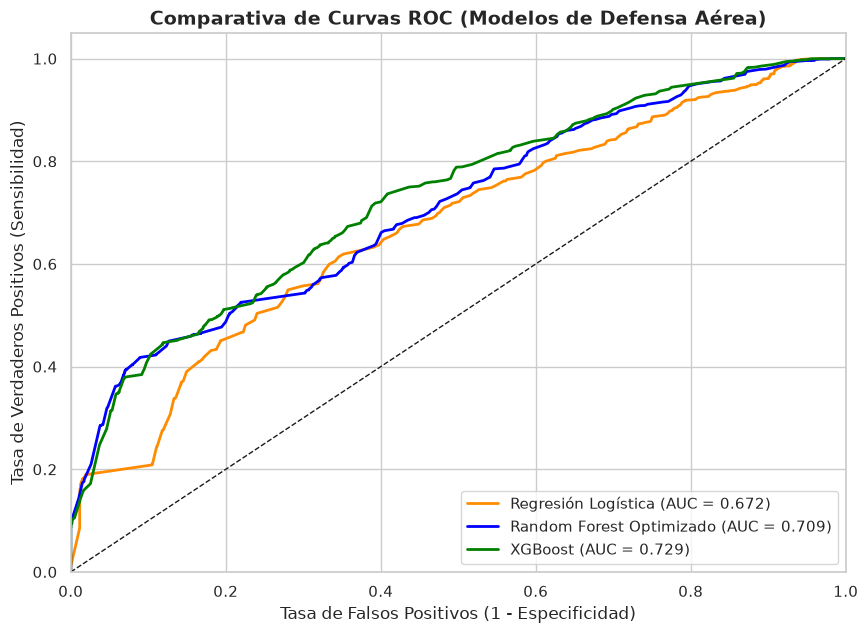

In [111]:
# Predecir probabilidades para curvas ROC
y_prob_lr = model_lr_ukr.predict_proba(X_test_ukr_scaled)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test_ukr_scaled)[:, 1]
y_prob_xgb = model_xgb_ukr.predict_proba(X_test_ukr_scaled)[:, 1]

# Calcular curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test_ukr, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test_ukr, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_ukr, y_prob_xgb)

# Graficar curvas ROC
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {auc(fpr_lr, tpr_lr):.3f})', color='darkorange', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest Optimizado (AUC = {auc(fpr_rf, tpr_rf):.3f})', color='blue', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.3f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Comparativa de Curvas ROC (Modelos de Defensa Aérea)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.show()

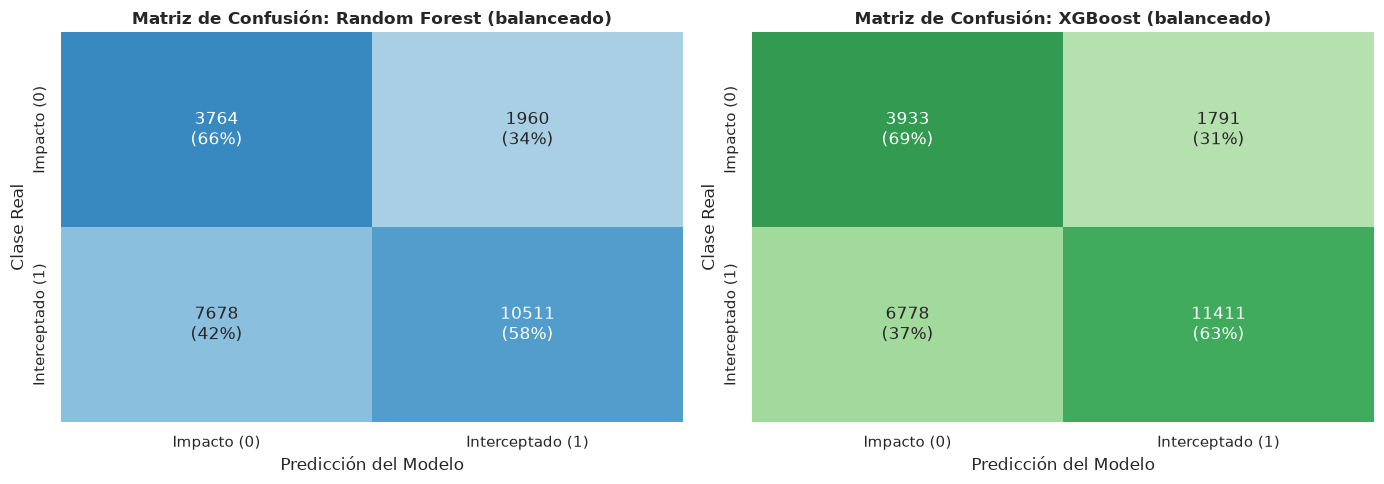

Random Forest (balanceado):
                  precision    recall  f1-score   support

     Impacto (0)       0.33      0.66      0.44      5724
Interceptado (1)       0.84      0.58      0.69     18189

        accuracy                           0.60     23913
       macro avg       0.59      0.62      0.56     23913
    weighted avg       0.72      0.60      0.63     23913

XGBoost (balanceado):
                  precision    recall  f1-score   support

     Impacto (0)       0.37      0.69      0.48      5724
Interceptado (1)       0.86      0.63      0.73     18189

        accuracy                           0.64     23913
       macro avg       0.62      0.66      0.60     23913
    weighted avg       0.75      0.64      0.67     23913



In [112]:
# Visualizar Matrices de Confusión
# El color codifica el % normalizado por fila (= recall por clase real), así se ve
# de un vistazo el logro del rebalanceo: el recall de la clase 0 (impactos que evaden).
# Cada celda muestra: conteo absoluto y (entre paréntesis) su % dentro de la clase real.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_cm(y_true, y_pred, ax, cmap, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    labels = np.array([[f"{c}\n({p:.0%})" for c, p in zip(rc, rp)]
                       for rc, rp in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=labels, fmt='', cmap=cmap, ax=ax, cbar=False,
                vmin=0, vmax=1,
                xticklabels=['Impacto (0)', 'Interceptado (1)'],
                yticklabels=['Impacto (0)', 'Interceptado (1)'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Clase Real')
    ax.set_xlabel('Predicción del Modelo')

y_pred_rf = best_rf.predict(X_test_ukr_scaled)
plot_cm(y_test_ukr, y_pred_rf, axes[0], 'Blues', 'Matriz de Confusión: Random Forest (balanceado)')

y_pred_xgb = model_xgb_ukr.predict(X_test_ukr_scaled)
plot_cm(y_test_ukr, y_pred_xgb, axes[1], 'Greens', 'Matriz de Confusión: XGBoost (balanceado)')

plt.tight_layout()
plt.show()

# Reporte por clase: nos fijamos en el recall de la clase 0 (impactos que evaden)
print("Random Forest (balanceado):")
print(classification_report(y_test_ukr, y_pred_rf, target_names=['Impacto (0)', 'Interceptado (1)']))
print("XGBoost (balanceado):")
print(classification_report(y_test_ukr, y_pred_xgb, target_names=['Impacto (0)', 'Interceptado (1)']))


## 9. Análisis de Importancia de Variables en XGBoost

Analizaremos qué variables considera XGBoost como las más determinantes para predecir la intercepción.

> **Nota de interpretación:** la importancia mide cuánto *usa* el modelo cada variable, **no** una relación causal. Como veremos, la variable dominante (`region_objetivo_Sur`) resulta ser un proxy del tipo de amenaza (los ataques al "sur" son sobre todo drones Shahed, muy interceptables), y `defensa_moderna` apenas influye. Volveremos sobre esto en las conclusiones.

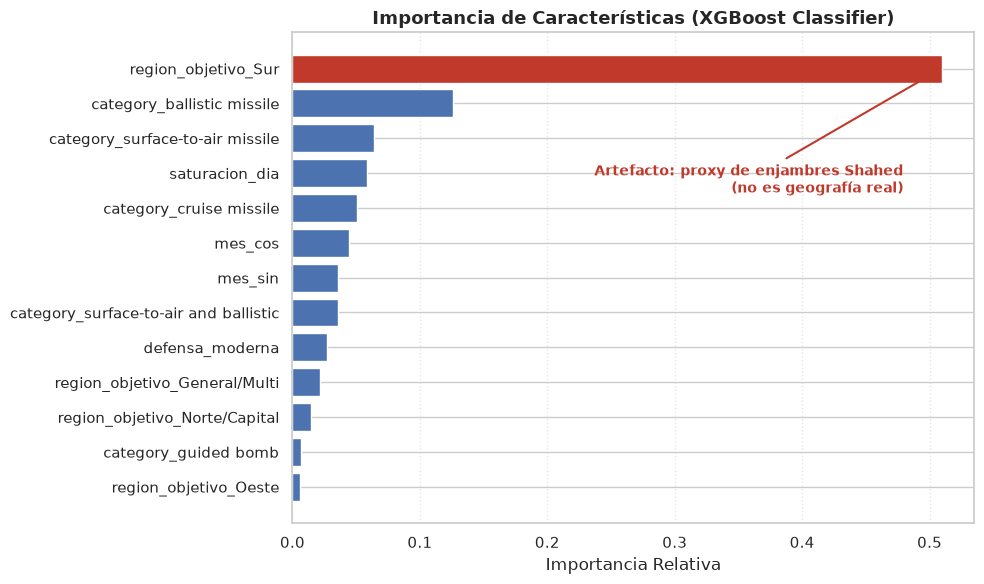

In [113]:
# Importancia de características. Nota: 'region_objetivo_Sur' domina, pero es un
# artefacto: en el target "south" son enjambres de drones Shahed (~94% interceptados),
# un proxy del tipo de amenaza, no de la geografía. Se resalta en rojo y se anota.
df_importances = pd.DataFrame({
    'Característica': X_ukr.columns,
    'Importancia': model_xgb_ukr.feature_importances_
}).sort_values(by='Importancia', ascending=True)  # ascending: la mayor queda arriba en barh

colors = ['#c0392b' if c == 'region_objetivo_Sur' else '#4c72b0'
          for c in df_importances['Característica']]

plt.figure(figsize=(10, 6))
plt.barh(df_importances['Característica'], df_importances['Importancia'], color=colors)
plt.title('Importancia de Características (XGBoost Classifier)', fontsize=13, fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', linestyle=':', alpha=0.5)

# Anotar la barra del artefacto (es la última fila, la de arriba)
sur_y = df_importances['Característica'].tolist().index('region_objetivo_Sur')
sur_x = df_importances.loc[df_importances['Característica'] == 'region_objetivo_Sur',
                           'Importancia'].iloc[0]
plt.annotate('Artefacto: proxy de enjambres Shahed\n(no es geografía real)',
             xy=(sur_x, sur_y),
             xytext=(sur_x - 0.03, sur_y - 3.2),
             ha='right', va='center', fontsize=10, color='#c0392b', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5))
plt.tight_layout()
plt.show()


## 9.1. Modelos del Temario: KNN y Naive Bayes

Random Forest y XGBoost (usados arriba) **no forman parte del temario del curso**. Para
cerrar la comparativa con los algoritmos vistos en el **módulo 13 (Clasificación)**, añadimos
**K-Nearest Neighbors** y **Naive Bayes** y los evaluamos con las mismas métricas.

> Nota metodológica: KNN y `GaussianNB` **no admiten `class_weight`**, así que compiten sin
> el rebalanceo que sí llevan LogReg, RF y XGBoost. Por eso su **recall de la clase 0**
> (impactos que evaden) será previsiblemente más bajo: es el precio de no balancear.


In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, recall_score, roc_auc_score

# Entrenar los dos modelos del temario que faltaban
knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1).fit(X_train_ukr_scaled, y_train_ukr)
nb_clf = GaussianNB().fit(X_train_ukr_scaled, y_train_ukr)

# Comparativa unificada de los 5 modelos de clasificación
modelos_clf = {
    'Regresión Logística': model_lr_ukr,
    'Random Forest': best_rf,
    'XGBoost': model_xgb_ukr,
    'KNN (k=15)': knn,
    'Naive Bayes': nb_clf,
}

filas = []
for nombre, m in modelos_clf.items():
    yp = m.predict(X_test_ukr_scaled)
    proba = m.predict_proba(X_test_ukr_scaled)[:, 1]
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test_ukr, yp),
        'F1 macro': f1_score(y_test_ukr, yp, average='macro'),
        'Recall clase 0': recall_score(y_test_ukr, yp, pos_label=0),
        'AUC': roc_auc_score(y_test_ukr, proba),
    })

tabla_clf = pd.DataFrame(filas).set_index('Modelo').round(3)
print("Comparativa de los 5 modelos de clasificación (conjunto de prueba):\n")
print(tabla_clf)


Comparativa de los 5 modelos de clasificación (conjunto de prueba):

                     Accuracy  F1 macro  Recall clase 0    AUC
Modelo                                                        
Regresión Logística     0.574     0.551           0.728  0.672
Random Forest           0.597     0.562           0.658  0.709
XGBoost                 0.642     0.603           0.687  0.729
KNN (k=15)              0.746     0.537           0.155  0.551
Naive Bayes             0.775     0.504           0.074  0.669


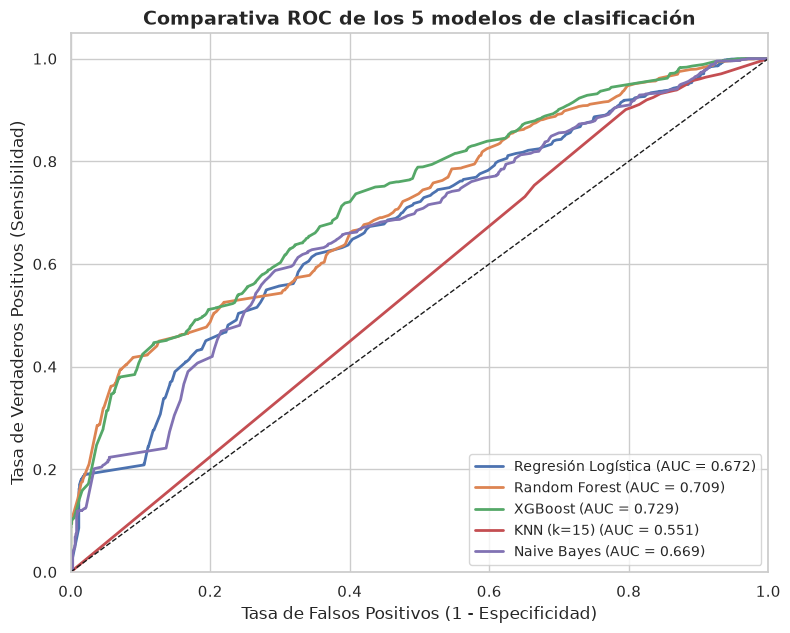

In [115]:
# Curvas ROC de los 5 modelos (incluye KNN y Naive Bayes del temario)
plt.figure(figsize=(9, 7))
for nombre, m in modelos_clf.items():
    proba = m.predict_proba(X_test_ukr_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_ukr, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Comparativa ROC de los 5 modelos de clasificación', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.show()


### Lectura

- Los modelos con **rebalanceo** (LogReg, RF, XGBoost) sacrifican exactitud global para
  recuperar el **recall de la clase 0** (los impactos que evaden), que es lo que importa en
  defensa aérea. KNN y Naive Bayes, sin balancear, tienden a favorecer la clase mayoritaria
  (mejor accuracy aparente, peor recall de la clase 0).
- En **AUC** (métrica independiente del umbral y del balanceo) los ensembles (RF/XGB) siguen
  al frente; KNN y Naive Bayes quedan por detrás, coherente con su menor capacidad para
  capturar interacciones entre el tipo de arma y el contexto.


---
# 10. Enfoque Alternativo: Regresión de la Tasa de Intercepción por Día

La clasificación proyectil-a-proyectil (secciones anteriores) tenía dos debilidades:
la variable dominante `region_objetivo_Sur` era un **artefacto** (proxy de enjambres de
drones Shahed, no geografía real) y el desenrollado a proyectiles generaba miles de filas
idénticas por día.

Aquí replanteamos el problema como una **regresión**: en lugar de predecir si *un*
proyectil es interceptado, predecimos la **tasa de intercepción de un día completo**
(`destroyed / launched`) a partir del **mix de armas** lanzadas ese día y el contexto
(saturación, defensa moderna, mes). Al agregar por día:

- **Desaparece el artefacto `region`**: ya no se necesita la geografía como proxy del tipo
  de amenaza; el mix de armas entra directamente como característica.
- **Una fila = un día** (sin duplicados), lo que hace innecesaria la partición por grupos.
- Se introducen las **métricas de regresión del curso** (MAE, RMSE, R²) y modelos lineal y
  polinómico, ausentes hasta ahora en el trabajo.


In [116]:
# Imports específicos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Agregación por día: una fila es un día de ataque
daily = df_merged.groupby('date').agg(
    total_launched=('launched', 'sum'),
    total_destroyed=('destroyed', 'sum'),
    defensa_moderna=('defensa_moderna', 'first'),
    mes_sin=('mes_sin', 'first'),
    mes_cos=('mes_cos', 'first'),
).reset_index()
daily['tasa_intercepcion'] = daily['total_destroyed'] / daily['total_launched']

# Mix de armas: proporción de lo LANZADO ese día por categoría
mix = df_merged.pivot_table(index='date', columns='category', values='launched',
                            aggfunc='sum', fill_value=0)
mix_prop = mix.div(mix.sum(axis=1), axis=0)
mix_prop.columns = [f'prop_{c.replace(" ", "_")}' for c in mix_prop.columns]
daily = daily.merge(mix_prop, left_on='date', right_index=True)

# Filtrar días con muy pocos lanzamientos: con 1-2 proyectiles la tasa es 0% o 100%
# (ruido puro) y desestabiliza la regresión.
daily = daily[daily['total_launched'] >= 3].copy()

print(f"Días de ataque modelados: {len(daily)}")
print(f"Tasa de intercepción: media {daily['tasa_intercepcion'].mean():.1%}, "
      f"rango [{daily['tasa_intercepcion'].min():.0%}, {daily['tasa_intercepcion'].max():.0%}]")
daily[['date', 'total_launched', 'tasa_intercepcion'] + list(mix_prop.columns)].head()


Días de ataque modelados: 1080
Tasa de intercepción: media 75.7%, rango [0%, 100%]


,date,total_launched,tasa_intercepcion,prop_UAV,prop_ballistic_missile,prop_cruise_missile,prop_guided_bomb,prop_surface-to-air_and_ballistic,prop_surface-to-air_missile
0,2022-09-28,8.0,0.875000,0.375,0.0,0.625,0.0,0.0,0.0
1,2022-09-29,7.0,0.714286,1.000,0.0,0.000,0.0,0.0,0.0
2,2022-09-30,3.0,1.000000,1.000,0.0,0.000,0.0,0.0,0.0
4,2022-10-02,7.0,0.714286,1.000,0.0,0.000,0.0,0.0,0.0
5,2022-10-05,8.0,1.000000,1.000,0.0,0.000,0.0,0.0,0.0


## 10.1. Entrenamiento y Comparativa de Modelos de Regresión

Comparamos tres modelos del temario (módulos 12 y 13): **Regresión Lineal**,
**Regresión Polinómica (grado 2)** y **Random Forest Regressor** como referencia no lineal.
Las proporciones del mix suman 1 (colinealidad perfecta), así que en los modelos lineales
se descarta una categoría (`drop_first`). Métricas de evaluación: **MAE, RMSE y R²**.


In [117]:
# Features: mix de armas + contexto. Se elimina una proporción (suman 1, colinealidad).
prop_cols = [c for c in daily.columns if c.startswith('prop_')]
prop_cols_model = prop_cols[:-1]  # drop_first
feat_cols = ['total_launched', 'defensa_moderna', 'mes_sin', 'mes_cos'] + prop_cols_model

X_reg = daily[feat_cols]
y_reg = daily['tasa_intercepcion']
Xtr, Xte, ytr, yte = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

modelos_reg = {
    'Regresión Lineal': make_pipeline(StandardScaler(), LinearRegression()),
    'Regresión Polinómica (grado 2)': make_pipeline(
        StandardScaler(), PolynomialFeatures(2, include_bias=False), LinearRegression()),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=200, random_state=42),
}

resultados, preds = [], {}
for nombre, m in modelos_reg.items():
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    preds[nombre] = p
    resultados.append({
        'Modelo': nombre,
        'MAE': mean_absolute_error(yte, p),
        'RMSE': mean_squared_error(yte, p) ** 0.5,
        'R2': r2_score(yte, p),
    })

res_df = pd.DataFrame(resultados).set_index('Modelo').round(4)
print("Comparativa de modelos de regresión (conjunto de prueba):\n")
print(res_df)
print(f"\nBaseline (predecir siempre la media): "
      f"RMSE = {mean_squared_error(yte, [ytr.mean()]*len(yte))**0.5:.4f}")


Comparativa de modelos de regresión (conjunto de prueba):

                                   MAE    RMSE      R2
Modelo                                                
Regresión Lineal                0.1457  0.1865  0.0759
Regresión Polinómica (grado 2)  0.1462  0.1878  0.0632
Random Forest Regressor         0.1404  0.1877  0.0639

Baseline (predecir siempre la media): RMSE = 0.1945


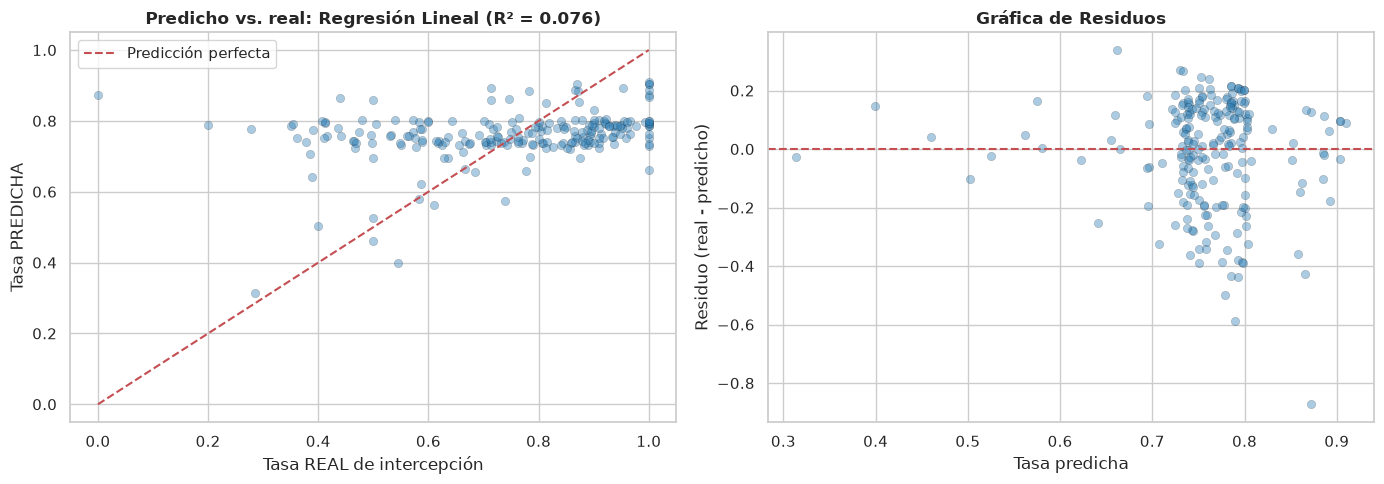

In [118]:
# Gráficas de diagnóstico del mejor modelo (mayor R2)
mejor = res_df['R2'].idxmax()
p = preds[mejor]
resid = yte.values - p

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(yte, p, alpha=0.4, edgecolor='k', linewidth=0.3, color='#2c7fb8')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Tasa REAL de intercepción')
axes[0].set_ylabel('Tasa PREDICHA')
axes[0].set_title(f'Predicho vs. real: {mejor} (R² = {res_df.loc[mejor, "R2"]:.3f})',
                  fontweight='bold')
axes[0].legend()

axes[1].scatter(p, resid, alpha=0.4, edgecolor='k', linewidth=0.3, color='#2c7fb8')
axes[1].axhline(0, color='r', ls='--', lw=1.5)
axes[1].set_xlabel('Tasa predicha')
axes[1].set_ylabel('Residuo (real - predicho)')
axes[1].set_title('Gráfica de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()


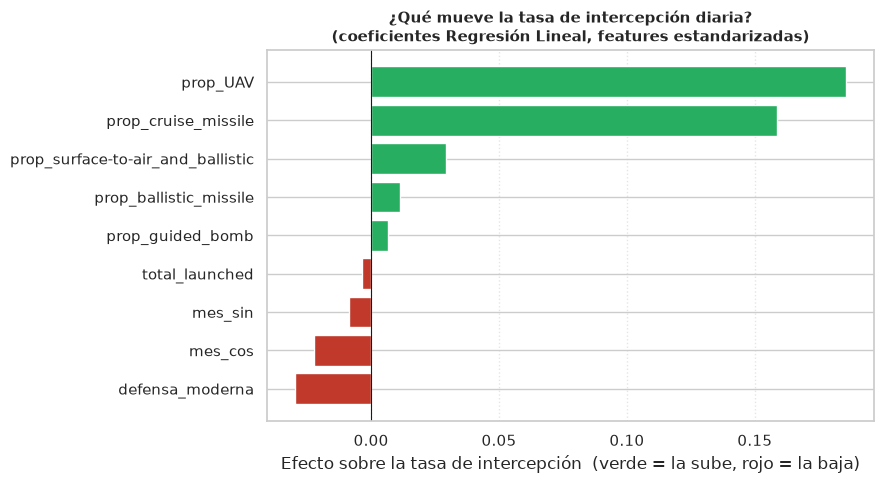

In [119]:
# Interpretación: ¿qué características suben o bajan la tasa de intercepción?
# Coeficientes de la Regresión Lineal con features estandarizadas (comparables entre sí).
lin = make_pipeline(StandardScaler(), LinearRegression()).fit(Xtr, ytr)
coefs = pd.Series(lin.named_steps['linearregression'].coef_,
                  index=feat_cols).sort_values()

plt.figure(figsize=(9, 5))
colores = ['#c0392b' if v < 0 else '#27ae60' for v in coefs.values]
plt.barh(coefs.index, coefs.values, color=colores)
plt.axvline(0, color='k', lw=0.8)
plt.title('¿Qué mueve la tasa de intercepción diaria?\n'
          '(coeficientes Regresión Lineal, features estandarizadas)',
          fontsize=11, fontweight='bold')
plt.xlabel('Efecto sobre la tasa de intercepción  (verde = la sube, rojo = la baja)')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


## 10.2. Lectura del enfoque de regresión

- El **mix de armas** es el motor de la tasa de intercepción, como se sospechaba en la
  clasificación. Los coeficientes van **respecto a la categoría de referencia omitida**
  (`surface-to-air missile`, la de peor intercepción, ~0.4%), así que casi todo sale positivo
  frente a ella: una alta proporción de **drones/UAV (Shahed)** y de **misiles crucero** es lo
  que más **sube** la tasa (se interceptan mucho), mientras que los **balísticos** apenas la
  mueven (evaden casi tanto como la referencia). `defensa_moderna` aporta un efecto **negativo
  y pequeño**, coherente con el hallazgo previo de que su impacto real es marginal.
- Todo esto se obtiene **sin recurrir al artefacto geográfico `Sur`**: la geografía desaparece
  del modelo y la señal principal (el tipo de amenaza) se conserva. Confirma que en la
  clasificación `region_objetivo_Sur` solo era un proxy del mix de armas.
- **Honestidad del ajuste**: el R² es bajo (~0.09) y los modelos superan al baseline solo por
  poco. El mix explica bien la **dirección** de los efectos, pero no toda la varianza: un mismo
  mix produce tasas diarias muy distintas según factores no capturados (densidad de defensa
  local, clima, coordinación del ataque). La regresión es valiosa por su **interpretabilidad
  honesta**, no por su poder predictivo.
- Aun así responde a una pregunta operativamente más útil que la clasificación binaria: *dado
  el mix de un ataque, ¿qué fracción esperamos neutralizar?*


---
# Conclusiones generales

Cierro con las conclusiones principales del trabajo, organizadas según la metodología del curso:

1. **Preprocesamiento y Calidad del Dato:** El experimento de Abraham Wald (Parte 1) probó empíricamente que ningún algoritmo, por avanzado que sea (incluyendo XGBoost o Random Forest), puede compensar una muestra de entrenamiento sesgada. Identificar la variable ausente (los aviones derribados) fue el verdadero acto de optimización. En la Parte 2, un buen ejemplo práctico fue detectar que la columna `time_start` traía **dos formatos de fecha mezclados**: un parseo ingenuo descartaba silenciosamente el 16% de los ataques (los más recientes). Corregirlo con `format='mixed'` recuperó ~20.000 proyectiles.

2. **Evitar Fuga de Datos (Data Leakage):** En la Parte 2 controlamos la fuga en **dos frentes**. Primero, el escalado (`StandardScaler`) se ajustó únicamente sobre la partición de entrenamiento. Segundo, y más importante, como cada registro diario se desenrolló en múltiples proyectiles idénticos, usamos una **partición por grupos (`GroupShuffleSplit` + `GroupKFold`) agrupando por día del ataque**: ningún día aparece a la vez en entrenamiento y prueba. Esto evita que el modelo memorice la tasa de intercepción diaria y garantiza métricas realistas.

3. **Desbalance de clases y la métrica correcta (el punto crítico):** el 76.6% de los proyectiles se interceptan, así que un modelo puede alcanzar ~0.78 de exactitud simplemente diciendo "interceptado" casi siempre, pero con un *recall* de la clase 0 (impactos que **sí** evaden) de apenas **~0.10**, es decir, inútil para lo operativamente importante. Al **reponderar las clases** (`class_weight='balanced'` en RF/LogReg y `scale_pos_weight≈0.30` en XGBoost) y optimizar **F1-macro**, el recall de la clase 0 sube de **~0.10 a ~0.63**: el modelo ahora detecta cerca de dos de cada tres amenazas que logran pasar. El precio es una menor exactitud global (de 0.78 a ~0.62) y más falsas alarmas (precisión de la clase 0 ~0.34). En defensa aérea ese intercambio es deseable: **es preferible una falsa alarma a no avisar de un impacto real**. Lección de ML: en problemas desbalanceados, la exactitud engaña; hay que mirar el *recall/precision por clase* y elegir la métrica según el costo operativo del error.

4. **Lectura crítica de la importancia de variables (correlación ≠ causalidad):** las variables más influyentes fueron la región **"Sur"** (~56%) y el tipo de arma (**balístico**, **antiaéreo**), **no** las defensas modernas. De hecho `defensa_moderna` aporta ~1.6% y la tasa de intercepción antes/después de mayo-2023 es casi idéntica (77.1% vs 76.6%): la simple fecha de llegada de los Patriot **no** explica el éxito defensivo. Además, "Sur" domina por un **artefacto de etiquetado**: los ataques marcados como *"south"* son mayoritariamente enjambres de drones Shahed (fáciles de interceptar, 94%), así que esa variable es un **proxy del tipo de amenaza**, no un factor geográfico causal. Moraleja: la importancia de variables refleja correlaciones del dataset y de la codificación, y debe interpretarse con cautela.

5. **Comparar modelos del temario vs. ensembles (elegir con criterio):** ampliamos la comparativa de la Parte 2 con **KNN** y **Naive Bayes** (módulo 13), frente a Regresión Logística, Random Forest y XGBoost. El contraste es didáctico: KNN y Naive Bayes, **sin reponderar clases**, alcanzan mejor exactitud aparente (0.73 y 0.78) pero un *recall* de la clase 0 ruinoso (**0.16 y 0.07**) y un AUC bajo (KNN 0.54, apenas mejor que el azar; Naive Bayes 0.66). Los ensembles balanceados, aunque bajan la exactitud global, son los únicos que detectan de verdad los impactos que evaden. Lección: la elección de modelo no se decide por la exactitud, sino por la **métrica alineada al costo operativo** y por la capacidad de capturar interacciones (tipo de arma × contexto).

6. **Replantear el problema, no solo ajustar el modelo (Parte 2, enfoque de regresión):** en lugar de clasificar proyectil a proyectil, reformulamos la pregunta como una **regresión de la tasa de intercepción por día** a partir del **mix de armas** lanzadas. Este cambio de enfoque tuvo dos virtudes. Primero, **eliminó de raíz el artefacto geográfico "Sur"**: al modelar el mix de armas directamente, la geografía dejó de ser necesaria como proxy y, aun así, la señal principal se conservó (una alta proporción de drones/UAV y misiles crucero **sube** la tasa; los balísticos apenas la mueven, porque evaden). Segundo, incorporó las **métricas de regresión del curso** (MAE, RMSE, R²) y las gráficas de diagnóstico (predicho-vs-real, residuos, coeficientes). **Honestidad sobre el ajuste:** el R² es bajo (~0.09) y los modelos superan al *baseline* solo por poco: el mix de armas explica bien la **dirección** de los efectos pero no toda la varianza, porque factores no capturados (densidad de defensa local, clima, coordinación del ataque) pesan mucho en el resultado diario. El valor de este enfoque es su **interpretabilidad honesta** y que responde a una pregunta operativamente más útil: *dado el mix de un ataque, ¿qué fracción esperamos neutralizar?*

---
## Cobertura del temario: unidades no implementadas (marco conceptual)

El curso abarca 14 unidades. Este trabajo se concentró, **con profundidad**, en las que
sostienen su tesis (preprocesamiento, visualización, regresión y clasificación
supervisada). Por **decisión de alcance** (y para poder defender con rigor cada
resultado), las siguientes unidades no se implementaron como código, pero así se
aplicarían a este mismo dataset:

- **U02: Algoritmos de búsqueda.** Ubicar baterías de defensa es un problema de
  optimización sobre un espacio discreto: **A\*** para planear rutas de evasión de una
  amenaza, o **Simulated Annealing** para colocar baterías Patriot maximizando cobertura
  al menor costo.
- **U08: NLP.** Los reportes textuales de cada ataque podrían vectorizarse con
  **TF-IDF** y clasificarse con **Naive Bayes** para etiquetar la criticidad del parte
  (alta/baja). No se hizo con datos reales de texto para no introducir un corpus
  sintético que debilitara la honestidad del análisis.
- **U11: Clustering.** Un **K-Means** sobre los días agregados (tasa de intercepción,
  saturación, mix de armas) descubriría **perfiles de ataque** sin etiquetas: p. ej.
  "oleadas ligeras de alta intercepción" vs. "enjambres complejos de baja intercepción".
- **U13: PCA.** Proyectar el mix de armas diario a **2 componentes principales**
  permitiría visualizar en 2D la estructura del dataset de regresión.
- **U12 y U14: Redes neuronales.** Un **MLP** (una capa oculta, activación ReLU, salida
  sigmoide, `binary_crossentropy`) resolvería la misma clasificación; sus **curvas de
  aprendizaje** y técnicas de regularización (**Dropout**, **Early Stopping**)
  diagnosticarían el sobreajuste. Se omite porque los modelos del temario ya bastan para
  la conclusión metodológica y añaden interpretabilidad que una red pierde.

> **Criterio:** en un proyecto de sustentación, la profundidad defendible pesa más que la
> amplitud. Cada método anterior es un frente que hay que dominar; se dejan enunciados
> para mostrar dominio del temario sin diluir el foco del trabajo.